In [1]:
import torch
from PIL import Image
from matplotlib import pyplot as plt
from augmentation import get_transform_steps_report
from dataset import train_csv_path, train_img_folder_path
import pandas as pd
from stats import mean, std

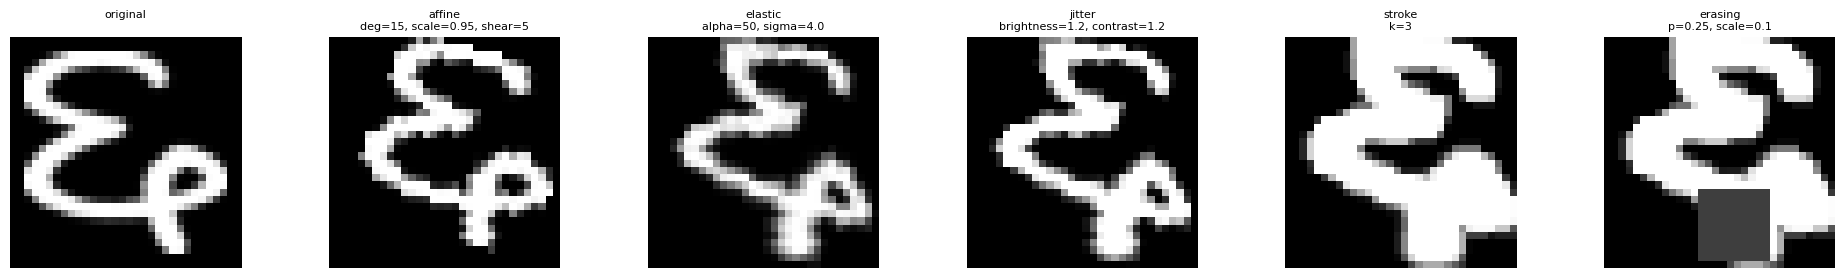

In [2]:
df= pd.read_csv(train_csv_path)
row = df.iloc[0]
img = Image.open (f"{train_img_folder_path}/{int(row['Category'])}/{int(row['Id'])}.png")
torch.manual_seed(42)
degrees = 15
scale = 0.95
shear = 5
elastic_alpha = 50
elastic_sigma = 4.0
brightness = 1.2
contrast = 1.2
#stroke_prob = 1
stroke_k =3
erasing_p = 0.25
erasing_scale = 0.1
steps = get_transform_steps_report(degree=degrees, scale=scale, shear=shear, elastic_alpha=elastic_alpha, elastic_sigma=elastic_sigma, brightness=brightness, contrast=contrast, stroke_k=stroke_k, erasing_p=erasing_p, erasing_scale=erasing_scale)
params = {"affine": f"deg={degrees}, scale={scale}, shear={shear}",
          "elastic": f"alpha={elastic_alpha}, sigma={elastic_sigma}",
          "jitter": f"brightness={brightness}, contrast={contrast}",
          "stroke": f"k={stroke_k}",
          "erasing": f"p={erasing_p}, scale={erasing_scale}",}
skip = {"grayscale", "resize", "to_tensor", "normalize"}
current = img
intermediates = [("original", current)]
for name,transform in steps:
    current = transform(current)
    if name not in skip:
        intermediates.append((name, current))
fig, axes = plt.subplots(1, len(intermediates), figsize=(24,3))
for ax, (name, img) in zip(axes, intermediates):
    if isinstance(img, torch.Tensor):
        display = (img * std +mean).clamp(0,1).squeeze(0)
        ax.imshow(display, cmap='gray')
    else:
        ax.imshow(img, cmap='gray')
    ax.set_title(f"{name}\n{params.get(name, '')}", fontsize=8)
    ax.axis('off')